# Course 3: Generative Models and Sequence Processing

## Complete Summary with Theory, Math, and Practice

This notebook covers the frontier of deep learning: **Generative Adversarial Networks (GANs)** for creating synthetic data, and the evolution of **sequence models** from RNNs through to the **Transformer** — the architecture powering modern AI.

---

## Table of Contents
1. [Generative Modeling Paradigm](#generative)
2. [Generative Adversarial Networks (GANs)](#gans)
3. [GAN Training Dynamics and Variants](#gan-variants)
4. [Recurrent Neural Networks (RNNs)](#rnns)
5. [LSTM and GRU: Solving Long-Term Dependencies](#lstm-gru)
6. [The Attention Mechanism](#attention)
7. [The Transformer Architecture](#transformer)
8. [Modern Applications: BERT, GPT, ViT](#modern)

---

<a name="generative"></a>
## 1. Generative Modeling: Teaching Machines to Create

### Discriminative vs. Generative Models

| | Discriminative | Generative |
|--|---------------|-----------|
| **Goal** | $P(y \mid \mathbf{x})$ — classify | $P(\mathbf{x})$ or $P(\mathbf{x} \mid y)$ — model the data |
| **Question** | "Is this a cat?" | "What does a cat look like?" |
| **Examples** | CNN classifier, logistic regression | GAN, VAE, diffusion models |
| **Use cases** | Classification, detection | Data synthesis, augmentation, art |

### Learning the Data Distribution

A generative model learns to sample from the true data distribution $p_{\text{data}}(\mathbf{x})$:

$$\mathbf{z} \sim p_z(\mathbf{z}), \quad \hat{\mathbf{x}} = G(\mathbf{z}) \approx p_{\text{data}}(\mathbf{x})$$

Where $\mathbf{z}$ is a **latent noise vector** (typically $\mathbf{z} \sim \mathcal{N}(0, I)$) and $G$ is a deep network.

### Key Generative Model Families

| Model | Core Idea | Strength | Weakness |
|-------|----------|---------|---------|
| **GAN** | Adversarial game G vs D | Sharp, high-quality images | Training instability |
| **VAE** | Probabilistic latent space | Smooth interpolation | Blurry samples |
| **Normalizing Flows** | Invertible transformations | Exact likelihood | Complex architecture |
| **Diffusion Models** | Reverse denoising process | State-of-the-art quality | Slow sampling |

### Applications Driving the Field

- **Synthetic data generation** for data augmentation
- **Image-to-image translation** (aerial photo ↔ map)
- **Super-resolution**: low-res → high-res
- **Text-to-image synthesis** (DALL-E, Midjourney, Stable Diffusion)
- **Drug discovery**: generate valid molecular structures

<a name="gans"></a>
## 2. Generative Adversarial Networks (GANs)

### The Adversarial Framework

Two networks compete in a **minimax game**:

**Generator $G$**: Maps noise $\mathbf{z} \sim p_z$ to fake samples $G(\mathbf{z})$  
**Discriminator $D$**: Maps samples $\mathbf{x}$ to probability of being real $D(\mathbf{x}) \in [0,1]$

```
     z ~ N(0,I) ──→ Generator G ──→ fake x
                                       │
     real data x ──────────────────────┼──→ Discriminator D ──→ real/fake?
```

### The Minimax Objective

$$\min_G \max_D V(D,G) = \mathbb{E}_{\mathbf{x} \sim p_{\text{data}}}[\log D(\mathbf{x})] + \mathbb{E}_{\mathbf{z} \sim p_z}[\log(1 - D(G(\mathbf{z})))]$$

**Discriminator** maximizes $V$: wants $D(\mathbf{x}_{\text{real}}) \to 1$ and $D(G(\mathbf{z})) \to 0$  
**Generator** minimizes $V$ (or equivalently maximizes $\mathbb{E}[\log D(G(\mathbf{z}))]$): wants $D(G(\mathbf{z})) \to 1$

### Training Procedure

**In practice**, alternate between:

1. **Update D** (freeze G): maximize $\mathbb{E}[\log D(\mathbf{x})] + \mathbb{E}[\log(1 - D(G(\mathbf{z})))]$
2. **Update G** (freeze D): maximize $\mathbb{E}[\log D(G(\mathbf{z}))]$ (non-saturating variant)

```python
# Pseudocode
for each batch:
    # Step 1: Train Discriminator
    real_loss = BCE(D(real_data), ones)
    fake_loss = BCE(D(G(noise).detach()), zeros)
    d_loss = real_loss + fake_loss
    d_optimizer.step(d_loss)
    
    # Step 2: Train Generator
    g_loss = BCE(D(G(noise)), ones)   # "fool D"
    g_optimizer.step(g_loss)
```

### The Nash Equilibrium

The optimal solution is when:
$$p_G(\mathbf{x}) = p_{\text{data}}(\mathbf{x}) \quad \text{(generator matches real distribution)}$$
$$D(\mathbf{x}) = \frac{1}{2} \quad \text{(discriminator can't distinguish real from fake)}$$

At this point, $V(D^*, G^*) = -\log 4 \approx -1.386$.

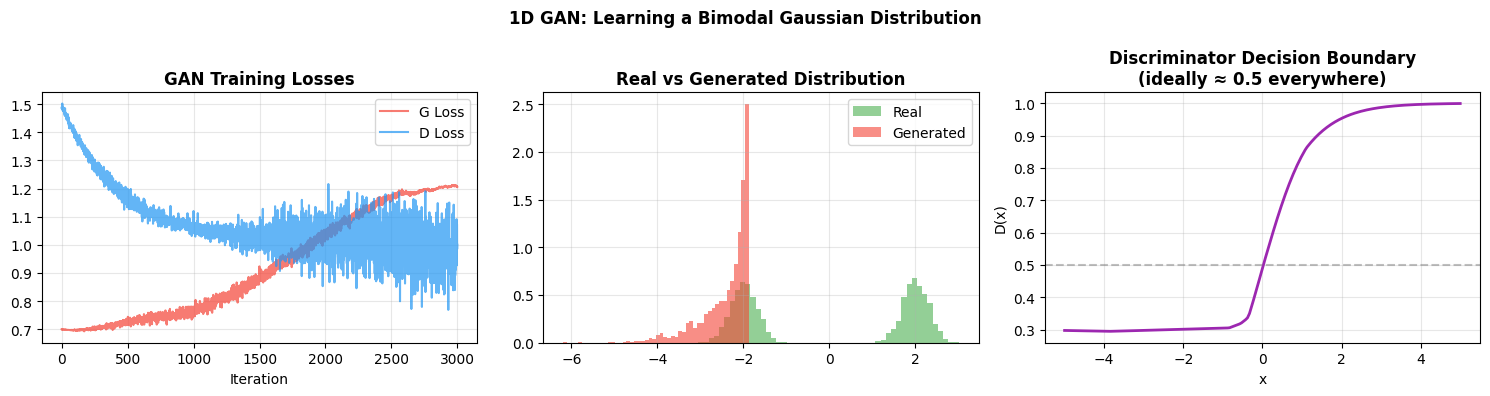

Real data:   mean=0.038, std=2.022
Generated:   mean=-2.400, std=0.578


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ── 1D GAN: learn to generate samples from a Gaussian mixture ─────────────────
np.random.seed(42)

def real_samples(n):
    """Bimodal Gaussian: 0.5 * N(-2, 0.3) + 0.5 * N(2, 0.3)"""
    means = np.where(np.random.rand(n) > 0.5, -2.0, 2.0)
    return means + np.random.randn(n) * 0.3

# Helper: simple 1-layer MLP
def mlp_forward(x, W1, b1, W2, b2, activation="relu"):
    z1 = W1 @ x + b1
    a1 = np.maximum(0, z1) if activation == "relu" else np.tanh(z1)
    z2 = W2 @ a1 + b2
    return z2, z1, a1

def sigmoid(z): return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

# Generator: z(1) → [16] → x(1)
Gw1 = np.random.randn(16, 1)*0.3; Gb1 = np.zeros((16,1))
Gw2 = np.random.randn(1,16)*0.3;  Gb2 = np.zeros((1,1))

# Discriminator: x(1) → [16] → prob(1)
Dw1 = np.random.randn(16, 1)*0.3; Db1 = np.zeros((16,1))
Dw2 = np.random.randn(1,16)*0.3;  Db2 = np.zeros((1,1))

lr, n_epochs, batch = 0.002, 3000, 64
g_losses, d_losses = [], []

def bce(y_pred, y_true, eps=1e-7):
    return -(y_true * np.log(y_pred + eps) + (1-y_true) * np.log(1 - y_pred + eps)).mean()

for ep in range(n_epochs):
    # ── Train Discriminator ────────────────────────────────────────────────────
    z = np.random.randn(1, batch)
    Gz, Gz1, Ga1 = mlp_forward(z, Gw1, Gb1, Gw2, Gb2)
    
    real = real_samples(batch).reshape(1, -1)
    
    # D(real) → 1, D(fake) → 0
    pr, Dr1, Da1_r = mlp_forward(real, Dw1, Db1, Dw2, Db2)
    pf, Df1, Da1_f = mlp_forward(Gz,   Dw1, Db1, Dw2, Db2)
    
    D_real = sigmoid(pr); D_fake = sigmoid(pf)
    d_loss = bce(D_real, np.ones_like(D_real)) + bce(D_fake, np.zeros_like(D_fake))
    d_losses.append(d_loss)

    # D backward (real)
    dpr = (D_real - 1) / batch
    dDw2 = dpr @ Da1_r.T; dDb2_r = dpr.sum(axis=1,keepdims=True)
    dDa1 = Dw2.T @ dpr * (Dr1 > 0)
    dDw1 = dDa1 @ real.T; dDb1_r = dDa1.sum(axis=1,keepdims=True)
    
    # D backward (fake)
    dpf = D_fake / batch
    dDw2_f = dpf @ Da1_f.T; dDb2_f = dpf.sum(axis=1,keepdims=True)
    dDa1_f = Dw2.T @ dpf * (Df1 > 0)
    dDw1_f = dDa1_f @ Gz.T; dDb1_f = dDa1_f.sum(axis=1,keepdims=True)
    
    Dw2 -= lr * (dDw2 + dDw2_f); Db2 -= lr * (dDb2_r + dDb2_f)
    Dw1 -= lr * (dDw1 + dDw1_f); Db1 -= lr * (dDb1_r + dDb1_f)
    
    # ── Train Generator ────────────────────────────────────────────────────────
    z2 = np.random.randn(1, batch)
    Gz2, Gz1_2, Ga1_2 = mlp_forward(z2, Gw1, Gb1, Gw2, Gb2)
    pf2, Df1_2, Da1_2= mlp_forward(Gz2, Dw1, Db1, Dw2, Db2)
    D_fake2 = sigmoid(pf2)
    
    g_loss = bce(D_fake2, np.ones_like(D_fake2))   # fool D
    g_losses.append(g_loss)
    
    # G backward: d_g_loss/d_Gz2
    dpf2 = (D_fake2 - 1) / batch
    dGz2 = (Dw1.T @ (Dw2.T @ dpf2 * (Df1_2 > 0)))  # gradient through D
    
    # G backward from dGz2
    dGa1 = Gw2.T @ dGz2 * (Gz1_2 > 0)
    Gw2 -= lr * (dGz2 @ Ga1_2.T); Gb2 -= lr * dGz2.sum(axis=1,keepdims=True)
    Gw1 -= lr * (dGa1 @ z2.T);    Gb1 -= lr * dGa1.sum(axis=1,keepdims=True)

# ── Visualize results ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Training curves
axes[0].plot(g_losses, label="G Loss", alpha=0.7, color="#F44336")
axes[0].plot(d_losses, label="D Loss", alpha=0.7, color="#2196F3")
axes[0].set_title("GAN Training Losses", fontweight="bold")
axes[0].set_xlabel("Iteration"); axes[0].legend(); axes[0].grid(alpha=0.3)

# Distribution comparison
z_test = np.random.randn(1, 2000)
fake, _, _ = mlp_forward(z_test, Gw1, Gb1, Gw2, Gb2)
fake = fake.squeeze()
real_test = real_samples(2000)

axes[1].hist(real_test, bins=50, alpha=0.6, density=True, color="#4CAF50", label="Real")
axes[1].hist(fake, bins=50, alpha=0.6, density=True, color="#F44336", label="Generated")
axes[1].set_title("Real vs Generated Distribution", fontweight="bold")
axes[1].legend(); axes[1].grid(alpha=0.3)

# Discriminator decision boundary
x_vals = np.linspace(-5, 5, 200).reshape(1, -1)
d_vals, _, _ = mlp_forward(x_vals, Dw1, Db1, Dw2, Db2)
d_prob = sigmoid(d_vals).squeeze()

axes[2].plot(x_vals.squeeze(), d_prob, color="#9C27B0", linewidth=2)
axes[2].axhline(0.5, color="gray", linestyle="--", alpha=0.5)
axes[2].set_title("Discriminator Decision Boundary\n(ideally ≈ 0.5 everywhere)", fontweight="bold")
axes[2].set_xlabel("x"); axes[2].set_ylabel("D(x)"); axes[2].grid(alpha=0.3)

plt.suptitle("1D GAN: Learning a Bimodal Gaussian Distribution", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

print(f"Real data:   mean={real_test.mean():.3f}, std={real_test.std():.3f}")
print(f"Generated:   mean={fake.mean():.3f}, std={fake.std():.3f}")

<a name="gan-variants"></a>
## 3. GAN Training Dynamics and Architectural Variants

### Common Failure Modes

| Problem | Symptoms | Fix |
|---------|----------|-----|
| **Mode collapse** | G generates same few outputs | Minibatch discrimination, Wasserstein loss |
| **Non-convergence** | Losses oscillate, no improvement | Lower LR, add noise to D inputs |
| **Vanishing gradients (D)** | G gradients ≈ 0 (D too good) | Non-saturating loss, label smoothing |
| **Training imbalance** | D too strong → G can't learn | Train D fewer times per G step |

### Training Tricks

1. **Label smoothing**: use $0.9$ instead of $1$ for real labels
2. **Add noise to D inputs**: makes D's job harder, prevents overfit
3. **Learning rate**: D often needs lower LR than G
4. **Spectral normalization**: normalize D weights by spectral norm

### Wasserstein GAN (WGAN)

Replace BCE loss with **Wasserstein distance** (Earth Mover's Distance):

$$W(p_{\text{data}}, p_G) = \sup_{\|f\|_L \leq 1} \mathbb{E}_{\mathbf{x} \sim p_{\text{data}}}[f(\mathbf{x})] - \mathbb{E}_{\mathbf{z} \sim p_z}[f(G(\mathbf{z}))]$$

Where $f$ is a 1-Lipschitz function (enforced via gradient penalty or weight clipping).

**Benefits:** More stable training, meaningful loss as training metric.

### Architectural Variants

#### DCGAN (Deep Convolutional GAN)
- G: FC → Reshape → Transposed Conv layers → Image
- D: Conv layers → FC → sigmoid
- BN in G (but not D output), Leaky ReLU in D, ReLU in G

#### Conditional GAN (cGAN)
Feed class label $y$ to both G and D:
$$\min_G \max_D V = \mathbb{E}[\log D(\mathbf{x}|y)] + \mathbb{E}[\log(1-D(G(\mathbf{z}|y)))]$$

#### CycleGAN — Unpaired Image-to-Image Translation

Learn mappings $G: X \to Y$ and $F: Y \to X$ with cycle-consistency loss:
$$\mathcal{L}_{\text{cyc}} = \mathbb{E}[\|F(G(\mathbf{x})) - \mathbf{x}\|_1] + \mathbb{E}[\|G(F(\mathbf{y})) - \mathbf{y}\|_1]$$

Applications: Day ↔ Night, Summer ↔ Winter, Photo ↔ Painting.

### Evaluation Metrics

| Metric | What It Measures | Higher is Better? |
|--------|-----------------|-----------------|
| **IS (Inception Score)** | Quality + diversity | ✅ Yes |
| **FID (Fréchet Inception Distance)** | Feature distribution similarity | ❌ Lower is better |
| **LPIPS** | Perceptual similarity | ❌ Lower is better |
| **Human evaluation** | Actual perceived quality | ✅ Preference rate |

<a name="rnns"></a>
## 4. Recurrent Neural Networks (RNNs)

### Why Standard Networks Fail for Sequences

| Issue | FC/CNN Problem | RNN Solution |
|-------|---------------|-------------|
| Variable-length input | Fixed input size | Processes one step at a time |
| Temporal dependencies | No memory | Hidden state carries history |
| Weight sharing across time | Independent layers | Same weights at each step |

### RNN Architecture

At each time step $t$:

$$\mathbf{h}_t = g(\mathbf{W}_{hh} \mathbf{h}_{t-1} + \mathbf{W}_{xh} \mathbf{x}_t + \mathbf{b}_h)$$
$$\hat{\mathbf{y}}_t = \mathbf{W}_{hy} \mathbf{h}_t + \mathbf{b}_y$$

Where:
- $\mathbf{h}_t \in \mathbb{R}^n$ is the **hidden state** (memory)
- $\mathbf{x}_t \in \mathbb{R}^d$ is the input at time $t$
- $\mathbf{W}_{hh}, \mathbf{W}_{xh}, \mathbf{W}_{hy}$ are **shared** across all time steps

### Unrolling Through Time

```
x₁ → [h₁] → x₂ → [h₂] → x₃ → [h₃] → ... → xₜ → [hₜ] → ŷ
       ↑─────────────↑───────────↑─────────────────────↑
                All share the same W_hh, W_xh, W_hy
```

### Backpropagation Through Time (BPTT)

Gradients flow backward through the unrolled network. For $T$ steps:

$$\frac{\partial \mathcal{L}}{\partial \mathbf{W}} = \sum_{t=1}^{T} \frac{\partial \mathcal{L}_t}{\partial \mathbf{h}_t} \prod_{k=t}^{T-1} \frac{\partial \mathbf{h}_{k+1}}{\partial \mathbf{h}_k}$$

The product $\prod_{k=t}^{T-1} \frac{\partial \mathbf{h}_{k+1}}{\partial \mathbf{h}_k}$ involves repeated multiplication by $\mathbf{W}_{hh}$.

- If $\|\mathbf{W}_{hh}\| < 1$: **vanishing gradients** — early inputs forgotten
- If $\|\mathbf{W}_{hh}\| > 1$: **exploding gradients** — fix with gradient clipping

### Use Cases

| Architecture | Input → Output | Example |
|-------------|----------------|---------|
| **Many-to-one** | Sequence → single | Sentiment analysis |
| **One-to-many** | Single → Sequence | Image captioning |
| **Many-to-many (synced)** | Seq → Seq (same length) | PoS tagging |
| **Many-to-many (encoder-decoder)** | Seq → Seq (diff length) | Machine translation |

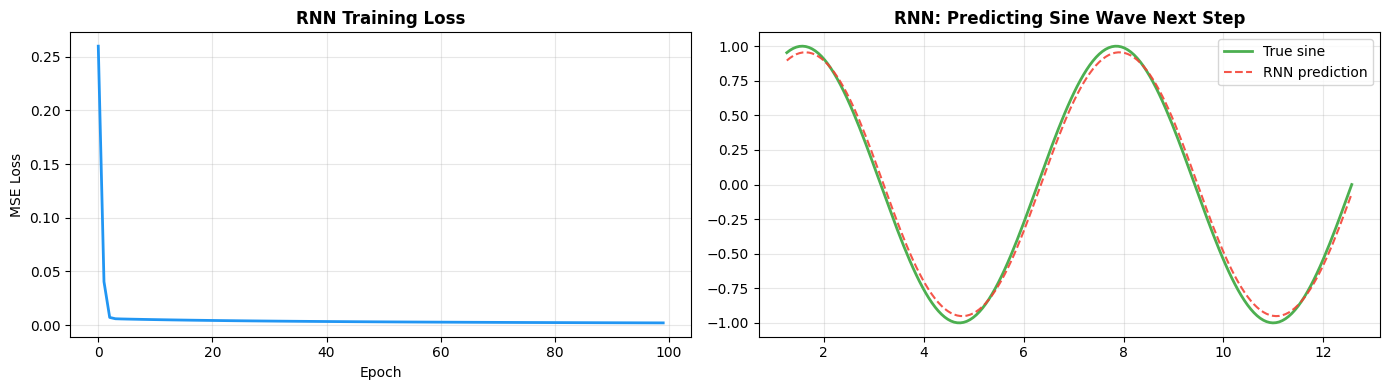

Final MSE on sine prediction: 0.002409


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ── Vanilla RNN: predict next value in a sine sequence ────────────────────────
np.random.seed(42)

# Data: sine wave
T_total = 200
t = np.linspace(0, 4 * np.pi, T_total)
data = np.sin(t)

seq_len = 20  # look-back window
X_seq = np.array([data[i:i+seq_len] for i in range(T_total - seq_len)])  # (180, 20)
y_seq = data[seq_len:T_total]                                              # (180,)

# Simple RNN cell: hidden size = 16
h_size, in_size = 16, 1
Wxh = np.random.randn(h_size, in_size) * 0.1
Whh = np.random.randn(h_size, h_size) * 0.1
bh  = np.zeros((h_size, 1))
Why = np.random.randn(1, h_size) * 0.1
by  = np.zeros((1, 1))

def rnn_forward(x_seq, h0):
    """x_seq: (T,), h0: (h_size, 1). Returns output scalar and all hidden states."""
    h = h0.copy()
    hs = []
    for t in range(len(x_seq)):
        x = np.array([[x_seq[t]]])   # (1, 1)
        h = np.tanh(Wxh @ x + Whh @ h + bh)
        hs.append(h.copy())
    y = Why @ h + by   # predict from last hidden state
    return y.item(), hs

lr, epochs = 0.005, 100
losses = []

for epoch in range(epochs):
    epoch_loss = 0
    for i in range(len(X_seq)):
        x_in = X_seq[i]
        y_true = y_seq[i]
        h0 = np.zeros((h_size, 1))
        
        # Forward
        y_pred, hs = rnn_forward(x_in, h0)
        loss = (y_pred - y_true) ** 2
        epoch_loss += loss
        
        # Backward (last-step only for simplicity — truncated BPTT)
        dy = 2 * (y_pred - y_true)
        dWhy = dy * hs[-1].T
        dby  = dy
        dh   = Why.T * dy * (1 - hs[-1]**2)   # tanh back

        # One step back through RNN
        x_last = np.array([[x_in[-1]]])
        h_prev = hs[-2] if len(hs) > 1 else np.zeros((h_size, 1))
        dWxh = dh @ x_last.T
        dWhh = dh @ h_prev.T
        dbh  = dh

        Why -= lr * dWhy; by -= lr * dby
        Wxh -= lr * dWxh; Whh -= lr * dWhh; bh -= lr * dbh

    losses.append(epoch_loss / len(X_seq))

# Generate predictions on the full sequence
preds = []
for i in range(len(X_seq)):
    y_pred, _ = rnn_forward(X_seq[i], np.zeros((h_size, 1)))
    preds.append(y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(losses, color="#2196F3", linewidth=2)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE Loss")
axes[0].set_title("RNN Training Loss", fontweight="bold"); axes[0].grid(alpha=0.3)

axes[1].plot(t[seq_len:], y_seq, label="True sine", color="#4CAF50", linewidth=2)
axes[1].plot(t[seq_len:], preds, label="RNN prediction", color="#F44336", 
             linewidth=1.5, linestyle="--", alpha=0.9)
axes[1].set_title("RNN: Predicting Sine Wave Next Step", fontweight="bold")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

mse = np.mean((np.array(preds) - y_seq)**2)
print(f"Final MSE on sine prediction: {mse:.6f}")

<a name="lstm-gru"></a>
## 5. LSTM and GRU: Solving Long-Term Dependencies

### Long Short-Term Memory (LSTM)

The LSTM adds a **cell state** $\mathbf{c}_t$ (long-term memory) alongside the hidden state $\mathbf{h}_t$, controlled by three learned **gates**:

**Forget gate** — what to erase from cell:
$$\mathbf{f}_t = \sigma(\mathbf{W}_f [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_f)$$

**Input gate** — what new information to add:
$$\mathbf{i}_t = \sigma(\mathbf{W}_i [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_i)$$
$$\tilde{\mathbf{c}}_t = \tanh(\mathbf{W}_c [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_c)$$

**Cell state update:**
$$\mathbf{c}_t = \mathbf{f}_t \odot \mathbf{c}_{t-1} + \mathbf{i}_t \odot \tilde{\mathbf{c}}_t$$

**Output gate** — what to output:
$$\mathbf{o}_t = \sigma(\mathbf{W}_o [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_o)$$
$$\mathbf{h}_t = \mathbf{o}_t \odot \tanh(\mathbf{c}_t)$$

The cell state highway $\mathbf{c}_t$ is analogous to ResNet's skip connection — **gradients can flow unchanged across many steps**.

### Gated Recurrent Unit (GRU)

A simplified LSTM with two gates (no separate cell state):

**Reset gate** — how much past to forget:
$$\mathbf{r}_t = \sigma(\mathbf{W}_r [\mathbf{h}_{t-1}, \mathbf{x}_t])$$

**Update gate** — how much to update:
$$\mathbf{z}_t = \sigma(\mathbf{W}_z [\mathbf{h}_{t-1}, \mathbf{x}_t])$$

**Candidate hidden state:**
$$\tilde{\mathbf{h}}_t = \tanh(\mathbf{W} [\mathbf{r}_t \odot \mathbf{h}_{t-1}, \mathbf{x}_t])$$

**Final hidden state:**
$$\mathbf{h}_t = (1 - \mathbf{z}_t) \odot \mathbf{h}_{t-1} + \mathbf{z}_t \odot \tilde{\mathbf{h}}_t$$

### LSTM vs GRU Comparison

| | LSTM | GRU |
|--|------|-----|
| Gates | 3 (forget, input, output) | 2 (reset, update) |
| Cell state | Separate $\mathbf{c}_t$ and $\mathbf{h}_t$ | Only $\mathbf{h}_t$ |
| Parameters | $4 \times$ vanilla RNN | $3 \times$ vanilla RNN |
| Performance | Slightly better on long sequences | Faster, often comparable |
| Default choice | Long sequences / complex tasks | Faster experimentation |

### Bidirectional RNNs

Run two RNNs: one forward, one backward, and **concatenate** their hidden states:

$$\mathbf{h}_t = [\overrightarrow{\mathbf{h}}_t; \overleftarrow{\mathbf{h}}_t]$$

Useful when context from **both directions** matters (e.g., speech recognition, NER).

> ⚠️ Cannot be used for **auto-regressive generation** (future is unknown at inference).

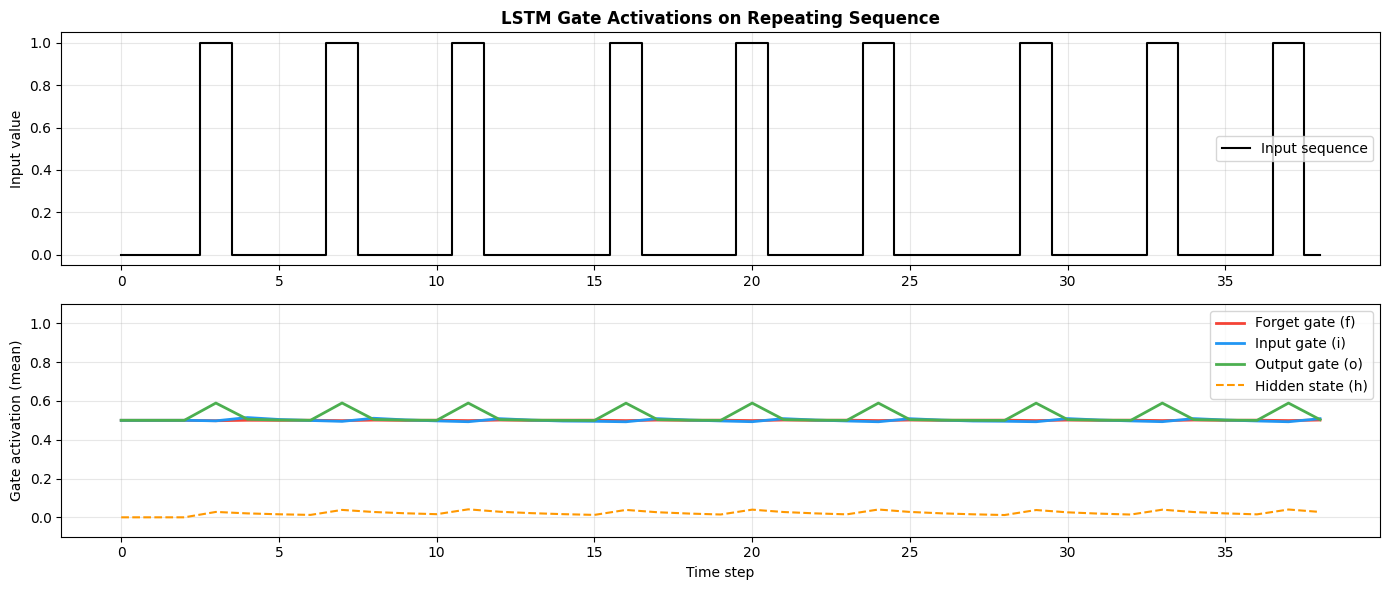

Hidden size = 64, Input size = 10

  Vanilla RNN params: 4,800
  GRU params:         14,400
  LSTM params:        19,200


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ── LSTM cell implementation from scratch ──────────────────────────────────────
np.random.seed(42)

class LSTMCell:
    def __init__(self, input_size, hidden_size):
        s = np.sqrt(2 / (input_size + hidden_size))
        # Forget, Input, Cell, Output gates — packed into one matrix for efficiency
        # [W_f, W_i, W_c, W_o] applied to [x_t, h_{t-1}]
        concat = input_size + hidden_size
        self.W = np.random.randn(4 * hidden_size, concat) * s
        self.b = np.zeros((4 * hidden_size, 1))
        self.hidden_size = hidden_size

    def sigmoid(self, x): return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

    def forward(self, x, h_prev, c_prev):
        """x: (input_size, 1), h_prev/c_prev: (hidden_size, 1)"""
        concat = np.vstack([x, h_prev])               # (input+hidden, 1)
        gates  = self.W @ concat + self.b             # (4*hidden, 1)
        
        n = self.hidden_size
        f = self.sigmoid(gates[0*n:1*n])              # forget gate
        i = self.sigmoid(gates[1*n:2*n])              # input gate
        c_bar = np.tanh(gates[2*n:3*n])               # candidate cell
        o = self.sigmoid(gates[3*n:4*n])              # output gate
        
        c = f * c_prev + i * c_bar                    # new cell state
        h = o * np.tanh(c)                            # new hidden state
        return h, c, (f, i, c_bar, o, concat)

# ── Visualise LSTM gate activations on a simple sequence ──────────────────────
cell = LSTMCell(input_size=1, hidden_size=8)

# Create a sequence: repeating pattern 0,0,0,1,0,0,0,1,...
seq = np.array([0,0,0,1,0,0,0,1,0,0,0,1,0] * 3, dtype=float)
T = len(seq)

h = np.zeros((8, 1)); c = np.zeros((8, 1))
f_hist, i_hist, o_hist = [], [], []
h_hist = []

for val in seq:
    x = np.array([[val]])
    h, c, (f, i, c_bar, o, _) = cell.forward(x, h, c)
    f_hist.append(f.mean()); i_hist.append(i.mean())
    o_hist.append(o.mean()); h_hist.append(h.mean())

fig, axes = plt.subplots(2, 1, figsize=(14, 6))

axes[0].step(range(T), seq, where="mid", color="k", label="Input sequence", linewidth=1.5)
axes[0].set_title("LSTM Gate Activations on Repeating Sequence", fontweight="bold")
axes[0].set_ylabel("Input value"); axes[0].grid(alpha=0.3); axes[0].legend()

axes[1].plot(f_hist, label="Forget gate (f)",  color="#F44336", linewidth=2)
axes[1].plot(i_hist, label="Input gate (i)",   color="#2196F3", linewidth=2)
axes[1].plot(o_hist, label="Output gate (o)",  color="#4CAF50", linewidth=2)
axes[1].plot(h_hist, label="Hidden state (h)", color="#FF9800", linewidth=1.5, linestyle="--")
axes[1].set_xlabel("Time step"); axes[1].set_ylabel("Gate activation (mean)")
axes[1].legend(loc="upper right"); axes[1].grid(alpha=0.3)
axes[1].set_ylim(-0.1, 1.1)

plt.tight_layout(); plt.show()

# ── Parameter count comparison ────────────────────────────────────────────────
h_size, x_size = 64, 10
print(f"Hidden size = {h_size}, Input size = {x_size}\n")
print(f"  Vanilla RNN params: {h_size*(h_size+x_size) + h_size:,}")
print(f"  GRU params:         {3*h_size*(h_size+x_size) + 3*h_size:,}")
print(f"  LSTM params:        {4*h_size*(h_size+x_size) + 4*h_size:,}")

<a name="attention"></a>
## 6. The Attention Mechanism

### The Core Intuition

*"When translating the word 'cat', focus on the relevant noun in the source sentence — not the whole sentence equally."*

Attention allows the model to **dynamically weight** different parts of the input:

$$\text{output}_t = \sum_s \alpha_{ts} \mathbf{h}_s$$

Where $\alpha_{ts}$ is the **attention weight** from output position $t$ to input position $s$.

### Scaled Dot-Product Attention

Given **queries** $\mathbf{Q}$, **keys** $\mathbf{K}$, **values** $\mathbf{V}$:

$$\text{Attention}(\mathbf{Q}, \mathbf{K}, \mathbf{V}) = \text{softmax}\!\left(\frac{\mathbf{Q}\mathbf{K}^T}{\sqrt{d_k}}\right) \mathbf{V}$$

Where:
- $\mathbf{Q} \in \mathbb{R}^{n \times d_k}$: queries (what we're looking for)
- $\mathbf{K} \in \mathbb{R}^{m \times d_k}$: keys (what we match against)
- $\mathbf{V} \in \mathbb{R}^{m \times d_v}$: values (what we return)
- $\sqrt{d_k}$: scaling prevents dot products from growing too large, keeping softmax gradients healthy

### Why the $\sqrt{d_k}$ Scaling?

For random unit-norm $\mathbf{q}$ and $\mathbf{k}$, $\mathbf{q} \cdot \mathbf{k}$ has variance $d_k$. Without scaling, after softmax, gradients vanish because one element dominates. Dividing by $\sqrt{d_k}$ keeps variance ≈ 1.

### Self-Attention

When $\mathbf{Q} = \mathbf{K} = \mathbf{V}$ (same sequence attending to itself):

Each token directly attends to **every other token** in the sequence. This gives $O(1)$ path length between any two positions vs. $O(T)$ for RNNs.

### Attention as Retrieval

| Component | Analogy | Role |
|-----------|---------|------|
| Query $\mathbf{q}$ | Search query | What you're looking for |
| Key $\mathbf{k}_i$ | Document tag | What each element offers |
| Value $\mathbf{v}_i$ | Document content | What each element returns |
| Score $\mathbf{q}\cdot\mathbf{k}_i$ | Relevance score | How well it matches |
| Weight $\alpha_i$ | Normalized score | How much to retrieve |

Self-Attention:
  Input shape:    (5, 8)
  Q/K/V shape:    (5, 4)
  Output shape:   (5, 4)
  Weights sum:    [1. 1. 1. 1. 1.]  (should all be 1.0)


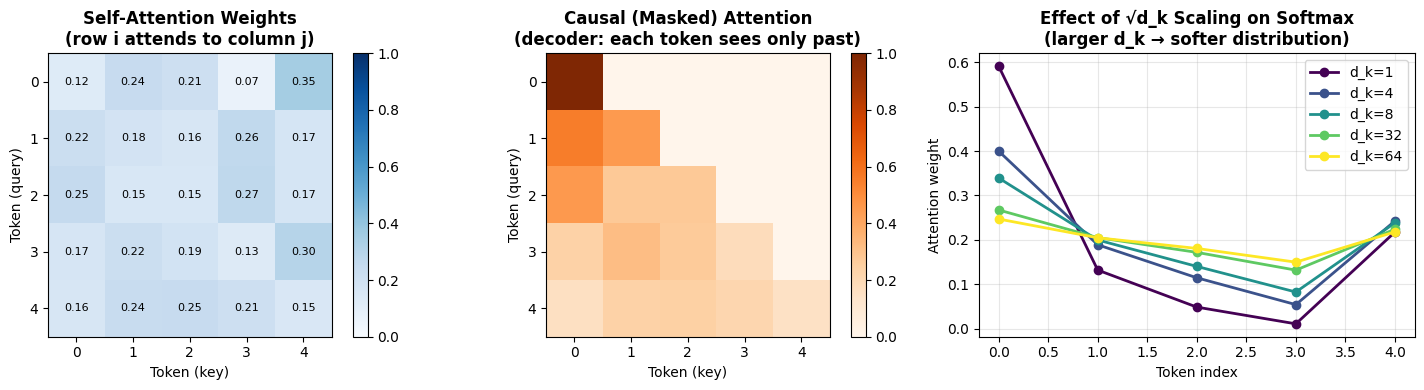

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ── Scaled Dot-Product Attention from scratch ──────────────────────────────────
np.random.seed(42)

def softmax(x, axis=-1):
    e = np.exp(x - x.max(axis=axis, keepdims=True))
    return e / e.sum(axis=axis, keepdims=True)

def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Q: (n_queries, d_k)
    K: (n_keys,   d_k)  
    V: (n_keys,   d_v)
    Returns: (n_queries, d_v), attention_weights: (n_queries, n_keys)
    """
    d_k = Q.shape[-1]
    scores = Q @ K.T / np.sqrt(d_k)           # (n_queries, n_keys)
    
    if mask is not None:
        scores = np.where(mask == 0, -1e9, scores)
    
    weights = softmax(scores, axis=-1)         # (n_queries, n_keys)
    output  = weights @ V                      # (n_queries, d_v)
    return output, weights

# ── Visualise self-attention on a toy 5-token sequence ──────────────────────── 
seq_len, d_model, d_k = 5, 8, 4

# Simulated token embeddings
X = np.random.randn(seq_len, d_model)  # (5, 8)

# Linear projections (Q, K, V)
Wq = np.random.randn(d_model, d_k) * 0.3   
Wk = np.random.randn(d_model, d_k) * 0.3
Wv = np.random.randn(d_model, d_k) * 0.3

Q = X @ Wq   # (5, 4)
K = X @ Wk   # (5, 4)
V = X @ Wv   # (5, 4)

output, attn_weights = scaled_dot_product_attention(Q, K, V)

print("Self-Attention:")
print(f"  Input shape:    {X.shape}")
print(f"  Q/K/V shape:    {Q.shape}")
print(f"  Output shape:   {output.shape}")
print(f"  Weights sum:    {attn_weights.sum(axis=-1).round(4)}  (should all be 1.0)")

# Visualize attention weights
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im1 = axes[0].imshow(attn_weights, cmap="Blues", vmin=0, vmax=1)
axes[0].set_title("Self-Attention Weights\n(row i attends to column j)", fontweight="bold")
axes[0].set_xlabel("Token (key)"); axes[0].set_ylabel("Token (query)")
plt.colorbar(im1, ax=axes[0])
for i in range(seq_len):
    for j in range(seq_len):
        axes[0].text(j, i, f"{attn_weights[i,j]:.2f}", ha="center", va="center", fontsize=8)

# Causal mask (used in decoders — can only attend to past tokens)
mask = np.tril(np.ones((seq_len, seq_len)))
_, causal_weights = scaled_dot_product_attention(Q, K, V, mask=mask)

im2 = axes[1].imshow(causal_weights, cmap="Oranges", vmin=0, vmax=1)
axes[1].set_title("Causal (Masked) Attention\n(decoder: each token sees only past)", fontweight="bold")
axes[1].set_xlabel("Token (key)"); axes[1].set_ylabel("Token (query)")
plt.colorbar(im2, ax=axes[1])

# Effect of scaling on softmax sharpness
d_vals = [1, 4, 8, 32, 64]
raw_score = np.array([3.0, 1.5, 0.5, -1.0, 2.0])
colors = plt.cm.viridis(np.linspace(0, 1, len(d_vals)))

for d, color in zip(d_vals, colors):
    w = softmax(raw_score / np.sqrt(d))
    axes[2].plot(w, label=f"d_k={d}", color=color, linewidth=2, marker="o")

axes[2].set_title("Effect of √d_k Scaling on Softmax\n(larger d_k → softer distribution)", fontweight="bold")
axes[2].set_xlabel("Token index"); axes[2].set_ylabel("Attention weight")
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

<a name="transformer"></a>
## 7. The Transformer Architecture
### "Attention is All You Need" (Vaswani et al., 2017)

### Overview

```
Encoder stack (N blocks)           Decoder stack (N blocks)
┌──────────────────────┐          ┌─────────────────────────────────┐
│  Multi-Head Self-Attn│          │  Masked Multi-Head Self-Attn    │
│  Add & Layer Norm    │          │  Add & Layer Norm               │
│  Feed-Forward (FFN)  │──ctx──→  │  Multi-Head Cross-Attention     │
│  Add & Layer Norm    │          │  Add & Layer Norm               │
│  (× N)               │          │  Feed-Forward (FFN)             │
└──────────────────────┘          │  Add & Layer Norm  (× N)        │
                                  └─────────────────────────────────┘
```

### Multi-Head Attention

Run $h$ attention heads **in parallel**, each with different linear projections:

$$\text{MultiHead}(\mathbf{Q},\mathbf{K},\mathbf{V}) = \text{Concat}(\text{head}_1,\ldots,\text{head}_h) \mathbf{W}^O$$

$$\text{head}_i = \text{Attention}(\mathbf{Q}\mathbf{W}_i^Q, \mathbf{K}\mathbf{W}_i^K, \mathbf{V}\mathbf{W}_i^V)$$

Each head can focus on **different aspects** of the sequence:
- One head: syntactic relationships
- Another: coreference
- Another: semantic similarity

### Positional Encoding

Transformers have no recurrence — they need **explicit position information**:

$$PE_{(pos, 2i)} = \sin\!\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)$$
$$PE_{(pos, 2i+1)} = \cos\!\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)$$

These sinusoidal functions allow the model to generalise to sequence lengths unseen during training, and for each position to be uniquely identifiable.

### Position-wise Feed-Forward Network

Applied identically at every position:

$$\text{FFN}(\mathbf{x}) = \max(0, \mathbf{x}\mathbf{W}_1 + \mathbf{b}_1)\mathbf{W}_2 + \mathbf{b}_2$$

Size: typically $d_{ff} = 4 \times d_{\text{model}}$ (e.g., 512 → 2048 → 512).

### Residual Connections + Layer Normalization

Each sub-layer uses:
$$\text{LayerNorm}(\mathbf{x} + \text{Sublayer}(\mathbf{x}))$$

This provides:
- **Skip connections** (like ResNet): prevent degradation
- **Layer normalization**: stabilizes training, independent of batch size

### Why Transformers Win Over RNNs

| Property | RNN/LSTM | Transformer |
|----------|----------|-------------|
| Parallelization | ❌ Sequential | ✅ Fully parallel |
| Max path length | $O(T)$ | $O(1)$ |
| Memory of position $1$ | Compressed in $\mathbf{h}_T$ | Direct attention |
| Training speed | Slow | Fast (GPU-efficient) |
| Scalability | Limited | Scales to 100B+ params |

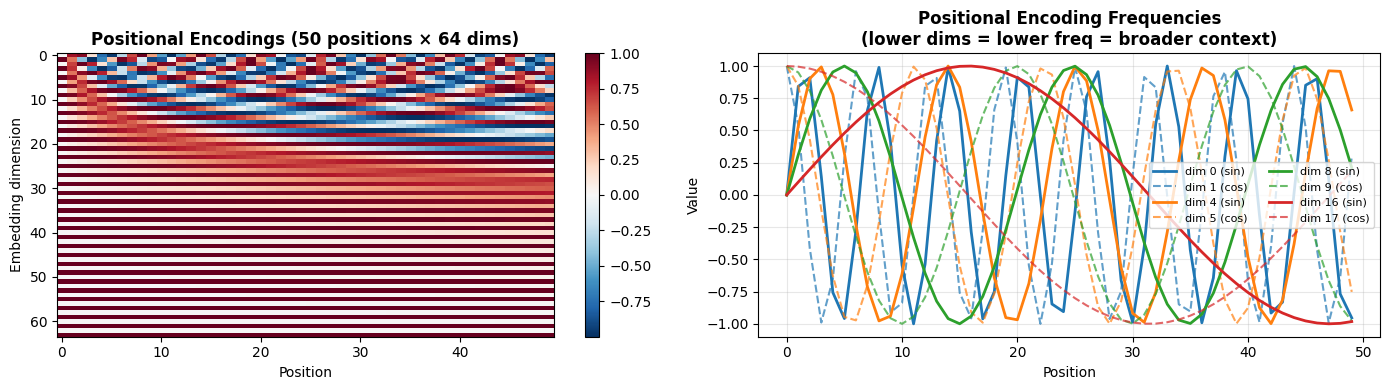

Multi-Head Self-Attention:
  Input:       (1, 8, 32)
  Output:      (1, 8, 32)
  Attn weights:(1, 4, 8, 8)  (batch, heads, query_pos, key_pos)


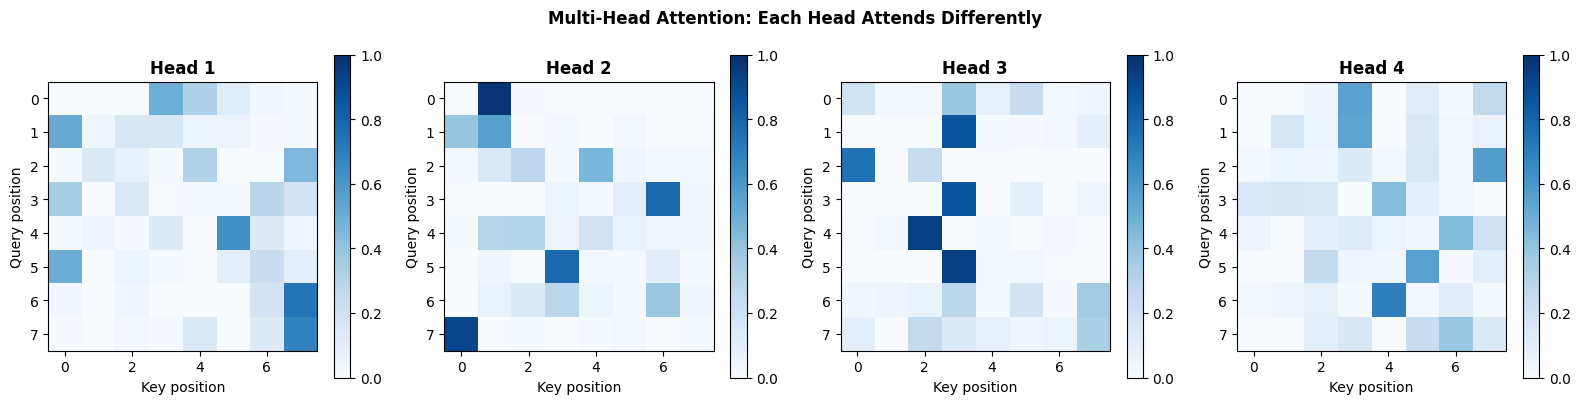

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ── Positional Encoding Visualization ─────────────────────────────────────────
def positional_encoding(max_len, d_model):
    PE = np.zeros((max_len, d_model))
    pos = np.arange(max_len)[:, np.newaxis]          # (max_len, 1)
    dims = np.arange(0, d_model, 2)                  # even indices
    div_term = np.power(10000, dims / d_model)        # (d_model/2,)
    PE[:, 0::2] = np.sin(pos / div_term)
    PE[:, 1::2] = np.cos(pos / div_term)
    return PE

PE = positional_encoding(max_len=50, d_model=64)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

im = axes[0].imshow(PE.T, cmap="RdBu_r", aspect="auto")
axes[0].set_xlabel("Position"); axes[0].set_ylabel("Embedding dimension")
axes[0].set_title("Positional Encodings (50 positions × 64 dims)", fontweight="bold")
plt.colorbar(im, ax=axes[0])

for i, dim_pair in enumerate([0, 4, 8, 16]):
    axes[1].plot(PE[:, dim_pair],   label=f"dim {dim_pair} (sin)",   
                 color=plt.cm.tab10(i), linewidth=2)
    axes[1].plot(PE[:, dim_pair+1], label=f"dim {dim_pair+1} (cos)", 
                 color=plt.cm.tab10(i), linestyle="--", linewidth=1.5, alpha=0.7)

axes[1].set_xlabel("Position"); axes[1].set_ylabel("Value")
axes[1].set_title("Positional Encoding Frequencies\n(lower dims = lower freq = broader context)", fontweight="bold")
axes[1].legend(fontsize=8, ncol=2); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# ── Multi-Head Attention implementation ───────────────────────────────────────
def softmax(x, axis=-1):
    e = np.exp(x - x.max(axis=axis, keepdims=True))
    return e / e.sum(axis=axis, keepdims=True)

class MultiHeadAttention:
    def __init__(self, d_model, num_heads):
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.h = num_heads
        self.d_k = d_model // num_heads
        # Weight matrices for all heads, packed together
        self.Wq = np.random.randn(d_model, d_model) * np.sqrt(2/d_model)
        self.Wk = np.random.randn(d_model, d_model) * np.sqrt(2/d_model)
        self.Wv = np.random.randn(d_model, d_model) * np.sqrt(2/d_model)
        self.Wo = np.random.randn(d_model, d_model) * np.sqrt(2/d_model)

    def split_heads(self, x, batch_size):
        """x: (batch, seq, d_model) → (batch, heads, seq, d_k)"""
        x = x.reshape(batch_size, -1, self.h, self.d_k)
        return x.transpose(0, 2, 1, 3)

    def forward(self, Q_in, K_in, V_in):
        batch = Q_in.shape[0]
        Q = (Q_in @ self.Wq)
        K = (K_in @ self.Wk)
        V = (V_in @ self.Wv)

        Q = self.split_heads(Q, batch)   # (B, H, T, d_k)
        K = self.split_heads(K, batch)
        V = self.split_heads(V, batch)

        scores = Q @ K.transpose(0,1,3,2) / np.sqrt(self.d_k)
        weights = softmax(scores, axis=-1)
        context = weights @ V               # (B, H, T, d_k)
        
        # Concatenate heads
        context = context.transpose(0,2,1,3).reshape(batch, -1, self.d_model)
        output  = context @ self.Wo
        return output, weights              # (B, T, d_model), (B, H, T, T)

np.random.seed(7)
batch_size, seq_len, d_model = 1, 8, 32
mha = MultiHeadAttention(d_model=d_model, num_heads=4)

X = np.random.randn(batch_size, seq_len, d_model)
out, weights = mha.forward(X, X, X)   # self-attention

print(f"Multi-Head Self-Attention:")
print(f"  Input:       {X.shape}")
print(f"  Output:      {out.shape}")
print(f"  Attn weights:{weights.shape}  (batch, heads, query_pos, key_pos)")

# Show each head's attention pattern
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for head_idx, ax in enumerate(axes):
    w = weights[0, head_idx]   # (seq, seq)
    im = ax.imshow(w, cmap="Blues", vmin=0, vmax=1)
    ax.set_title(f"Head {head_idx+1}", fontweight="bold")
    ax.set_xlabel("Key position"); ax.set_ylabel("Query position")
    plt.colorbar(im, ax=ax)

plt.suptitle("Multi-Head Attention: Each Head Attends Differently", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

<a name="modern"></a>
## 8. Modern Applications: BERT, GPT, and Vision Transformers

### BERT: Bidirectional Encoder Representations from Transformers

**Architecture:** Transformer **encoder** stack (no decoder)  
**Pre-training tasks:**
1. **Masked Language Modeling (MLM)**: mask 15% of tokens → predict them
2. **Next Sentence Prediction (NSP)**: predict if sentence B follows sentence A

$$\text{Input:} \quad [\text{CLS}] \; w_1 \; w_2 \; \cdots \; [\text{MASK}] \; \cdots \; [\text{SEP}]$$

**Why bidirectional?** Each token attends to **all** other tokens (no causal mask) — ideal for understanding.

**Fine-tuning:** Attach a task-specific head to the `[CLS]` token or all positions:
- Classification: `[CLS]` → FC → labels
- NER/POS: each token → FC → labels
- Q&A: predict start/end span positions

### GPT: Generative Pre-trained Transformer

**Architecture:** Transformer **decoder** stack with causal masking  
**Pre-training:** Autoregressive language modeling — predict next token:

$$\mathcal{L} = -\sum_{t=1}^{T} \log P(w_t \mid w_1, \ldots, w_{t-1})$$

**Key insight:** Causal self-attention — each position only attends to earlier positions, enabling **generation** token by token.

| | BERT | GPT |
|--|------|-----|
| Architecture | Encoder | Decoder |
| Attention | Bi-directional | Uni-directional (causal) |
| Pre-training | MLM + NSP | Autoregressive LM |
| Strength | Understanding, classification | Generation, completion |

### Vision Transformer (ViT)

Apply the Transformer directly to images by treating **patches as tokens**:

1. Split $H \times W$ image into $N = \frac{HW}{P^2}$ patches of size $P \times P$
2. Flatten each patch → linear projection → patch embedding
3. Add positional embedding + `[CLS]` token
4. Feed through Transformer encoder
5. Use `[CLS]` embedding for classification

$$x_i = \text{patch}_i \cdot \mathbf{W}_{\text{embed}} + \mathbf{e}_i^{pos}$$

**Scaling law:** ViT outperforms CNNs when trained on very large datasets (300M+ images). On smaller datasets, CNNs' inductive biases (locality, translation invariance) still help.

### The Path to Large Language Models

```
Transformer (2017) → GPT-1 (117M) → BERT (340M) → GPT-2 (1.5B) 
→ GPT-3 (175B) → InstructGPT → ChatGPT/GPT-4 → Claude, Gemini...
```

**Scaling laws** (Kaplan et al., 2020): Loss $\propto N^{-\alpha}$ (model size), $D^{-\beta}$ (data), $C^{-\gamma}$ (compute) — performance improves predictably with scale.

---
## ✅ Course 3 Key Takeaways

**Generative Models:**
- GANs = adversarial game: Generator vs Discriminator
- Minimax objective, Nash equilibrium at $p_G = p_{\text{data}}$
- Mode collapse and non-convergence are key training challenges
- WGAN improves stability; conditional GANs enable controlled generation

**Sequence Models:**
- RNNs: hidden state as memory, but suffer from vanishing gradients
- LSTM/GRU: gating mechanisms allow selective memory across hundreds of steps
- **Attention** $= \text{softmax}(\mathbf{QK}^T/\sqrt{d_k})\mathbf{V}$: dynamic, position-free weighting
- **Transformers** = multi-head attention + positional encoding + FFN + residuals
- BERT (encoder) for understanding; GPT (decoder) for generation
- ViT shows attention also works for vision at sufficient scale